## CODE FOR BREAKING DATASET DO NOT RUN

In [34]:
# import pandas as pd

# # Load the original dataset
# df_original = pd.read_csv('RFLFSODataFull.csv')

# # Take a random sample of 10% of the dataset
# df_sample = df_original.sample(frac=0.1, random_state=42)

# # Save the sampled dataset back to the same directory with a new name
# df_sample.to_csv('RFLFSODataFull_sample.csv', index=False)


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("notebook", font_scale=1.1)


# Data pre-processing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Feature engineering
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer

# modelling specifics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV


In [36]:
# Load the dataset

df = pd.read_csv('RFLFSODataFull.csv')
df = df.sample(frac=0.1, random_state=42)




## Data pre-processing

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the preprocessing steps based on the provided guidance
def preprocess_data(df, num_features, cat_features):
    # Convert NaN values to a new category for categorical variables 'SYNOPCode'
    # df['SYNOPCode'] = df['SYNOPCode'].fillna('missing').astype(str)
    
    
    SYNOP_mapping = {
        0: 'Clear',
        3: 'Dust Storm',
        4: 'Fog',
        5: 'Drizzle',
        6: 'Rain',
        7: 'Snow',
        8: 'Showers',
        9999: 'missing'
    }

    # Replace the numerical categories with strings
    # df['SYNOPCode'] = df['SYNOPCode'].map(SYNOP_mapping).fillna(df['SYNOPCode'])
    df['SYNOPCode'] = df['SYNOPCode'].map(SYNOP_mapping).fillna(df['SYNOPCode']).astype(str)
    

    # Define preprocessor
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Create and return the column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features)
        ])

    return preprocessor

# Extracting numerical and categorical features
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

# Removing target variables from features list
num_features.remove('FSO_Att')
num_features.remove('RFL_Att')
# cat_features.append('SYNOPCode')


# Applying preprocessing
preprocessor = preprocess_data(df, num_features, cat_features)

# Checking the transformation steps in the preprocessor
preprocessor.transformers
df.columns

Index(['FSO_Att', 'RFL_Att', 'AbsoluteHumidity', 'AbsoluteHumidityMax',
       'AbsoluteHumidityMin', 'Distance', 'Frequency', 'Particulate',
       'ParticulateMax', 'ParticulateMin', 'RainIntensity', 'RainIntensityMax',
       'RainIntensityMin', 'RelativeHumidity', 'SYNOPCode', 'Temperature',
       'TemperatureDifference', 'TemperatureMax', 'TemperatureMin', 'Time',
       'Visibility', 'VisibilityMax', 'VisibilityMin', 'WindDirection',
       'WindSpeed', 'WindSpeedMax', 'WindSpeedMin'],
      dtype='object')

# Independent random forest model


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np



# Function to build and evaluate a Random Forest model with added feature importance graph details
def build_and_evaluate_rf_model_with_graph(df, target_column, preprocessor, feature_names):
    # Data Preprocessing using the preprocessor
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Fit and transform the data using preprocessor
    X = preprocessor.fit_transform(X)
    
    # Splitting the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Model Building
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Feature Importance
    # importances = model.feature_importances_
    # indices = np.argsort(importances)[::-1]
    # plt.figure(figsize=(12, 6))
    # plt.title(f"Feature Importances for {target_column}")
    # plt.bar(range(X_train.shape[1]), importances[indices], align="center")
    # plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=80)
    # plt.xlabel('Features')
    # plt.ylabel('Importance')
    # plt.grid(True)
    # plt.show()
    
    return {
        'Model': model,
        'Metrics': {
            'RMSE': rmse,
            'R2 Score': r2
        }
    }

# Extract feature names
feature_names = num_features + [f"{cat_feature}_{category}" for cat_feature in cat_features for category in df[cat_feature].unique()]

# Build and evaluate models using the fitted preprocessor on the sampled dataset with enhanced graphs
fso_model_result_sampled = build_and_evaluate_rf_model_with_graph(df, 'FSO_Att', preprocessor, feature_names)
rfl_model_result_sampled = build_and_evaluate_rf_model_with_graph(df, 'RFL_Att', preprocessor, feature_names)

fso_model_result_sampled['Metrics'], rfl_model_result_sampled['Metrics']



({'RMSE': 1.3389534647013532, 'R2 Score': 0.8904592811936974},
 {'RMSE': 0.8597975331603385, 'R2 Score': 0.9442451219123561})

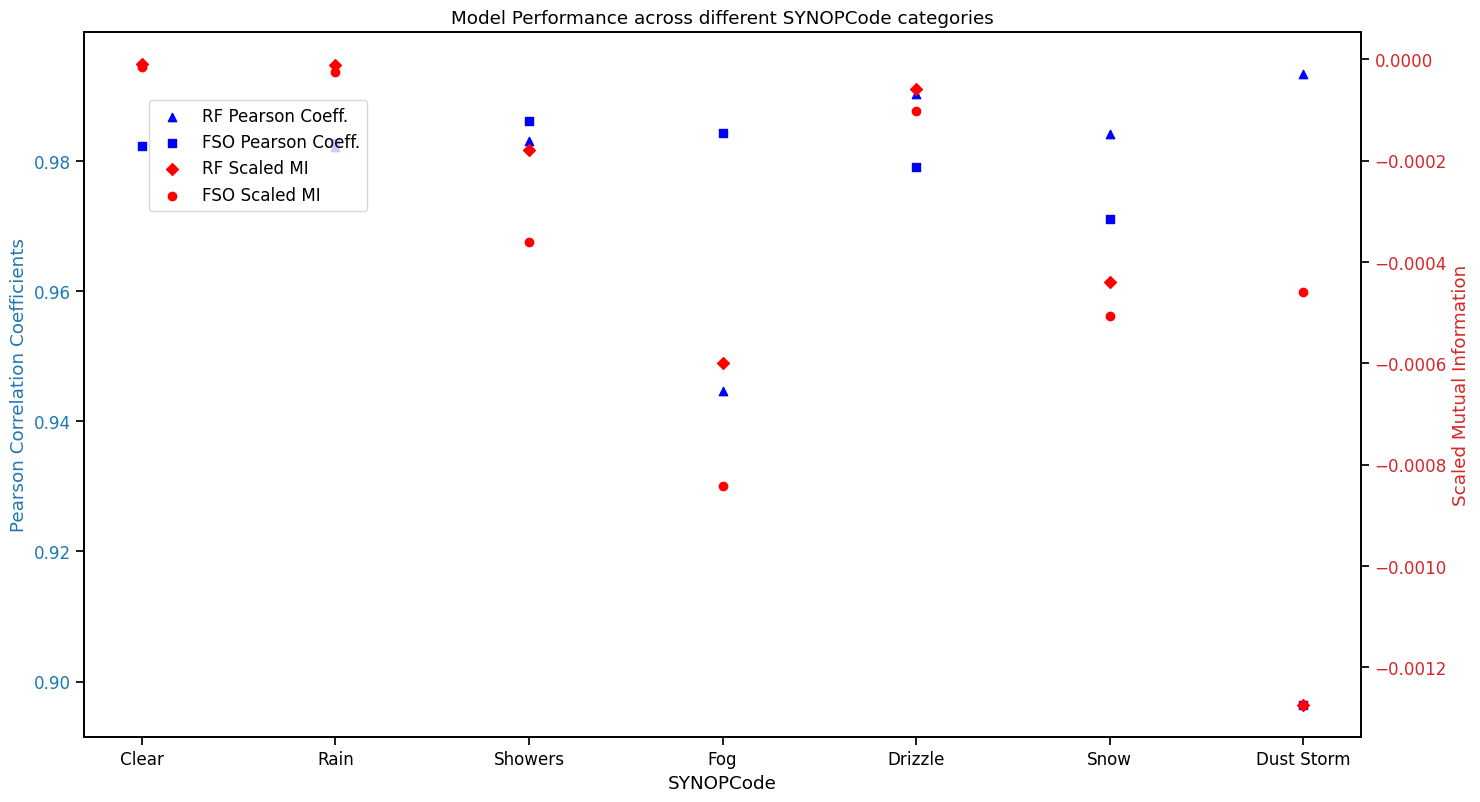

In [7]:
# Importing libraries required for Pearson correlation and mutual information
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate mutual information scaled by joint entropy
def scaled_mutual_info(x, y):
    mi = mutual_info_regression(x.reshape(-1, 1), y)[0]
    joint_entropy = -np.sum(x * np.log(x) + y * np.log(y))
    return mi / joint_entropy

# Initialize lists to store metrics
pearson_coeffs = []
scaled_mi = []
synop_codes = []

# Loop through each unique SYNOPCode to collect data and calculate metrics
for synop_code in df['SYNOPCode'].unique():
    sub_df = df[df['SYNOPCode'] == synop_code]
    
    # Data Collection
    actual_rf = sub_df['RFL_Att'].values
    actual_fso = sub_df['FSO_Att'].values
    
    # Predict using the trained models
    X = preprocessor.transform(sub_df.drop(columns=['FSO_Att', 'RFL_Att']))
    predicted_rf = rfl_model_result_sampled['Model'].predict(X)
    predicted_fso = fso_model_result_sampled['Model'].predict(X)
    
    # Pearson Correlation Coefficients
    pearson_rf, _ = pearsonr(actual_rf, predicted_rf)
    pearson_fso, _ = pearsonr(actual_fso, predicted_fso)
    
    # Scaled Mutual Information
    scaled_mi_rf = scaled_mutual_info(actual_rf, predicted_rf)
    scaled_mi_fso = scaled_mutual_info(actual_fso, predicted_fso)
    
    # Store metrics
    pearson_coeffs.append((pearson_rf, pearson_fso))
    scaled_mi.append((scaled_mi_rf, scaled_mi_fso))
    synop_codes.append(synop_code)

# Convert lists to numpy arrays for easier plotting
pearson_coeffs = np.array(pearson_coeffs)
scaled_mi = np.array(scaled_mi)

# Visualization
fig, ax1 = plt.subplots(figsize=(15, 8))

# Pearson correlation coefficients
ax1.set_xlabel('SYNOPCode')
ax1.set_ylabel('Pearson Correlation Coefficients', color='tab:blue')
ax1.scatter(synop_codes, pearson_coeffs[:, 0], marker='^', color='blue', label='RF Pearson Coeff.')
ax1.scatter(synop_codes, pearson_coeffs[:, 1], marker='s', color='blue', label='FSO Pearson Coeff.')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Scaled Mutual Information
ax2 = ax1.twinx()
ax2.set_ylabel('Scaled Mutual Information', color='tab:red')
ax2.scatter(synop_codes, scaled_mi[:, 0], marker='D', color='red', label='RF Scaled MI')
ax2.scatter(synop_codes, scaled_mi[:, 1], marker='o', color='red', label='FSO Scaled MI')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legends and title
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.title('Model Performance across different SYNOPCode categories')
plt.show()


## Cascading random forest model

In [19]:
# Importing necessary libraries for data manipulation and model building
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Function to build and evaluate a cascading Random Forest Regressor model
def build_and_evaluate_cascading_rf(df, target_columns, scaler, preprocess_func=None, feature_eng_func=None, subset_size=0.1):
    """
    Build and evaluate a cascading Random Forest Regressor model.
    
    Parameters:
    df (DataFrame): The input DataFrame.
    target_columns (list): List of target columns to be predicted.
    scaler (StandardScaler): Scaler for feature scaling.
    preprocess_func (function, optional): Preprocessing function.
    feature_eng_func (function, optional): Feature engineering function.
    subset_size (float): Fraction of data to use for model building.
    
    Returns:
    dict: Dictionary containing the models and evaluation metrics.
    """
    
    # Data Preprocessing
    if preprocess_func:
        df = preprocess_func(df)
        
    # Feature Engineering
    if feature_eng_func:
        df = feature_eng_func(df)
    
    # Use a subset of the data to avoid timeout
    df_subset = df.sample(frac=subset_size, random_state=42)
    
    # Initial split for the first target
    X1 = df_subset.drop(columns=target_columns)
    y1 = df_subset[target_columns[0]]
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
    
    # Feature Scaling for the first target
    X1_train = scaler.fit_transform(X1_train)
    X1_test = scaler.transform(X1_test)
    
    # Model Building for the first target
    model1 = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None, 
                                   max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
    model1.fit(X1_train, y1_train)
    
    # Prediction for the first target
    y1_pred_train = model1.predict(X1_train)
    y1_pred_test = model1.predict(X1_test)
    
    # Prepare data for the second target
    X2_train = np.column_stack((X1_train, y1_pred_train))
    X2_test = np.column_stack((X1_test, y1_pred_test))
    y2 = df_subset[target_columns[1]]
    y2_train = y2[y1_train.index]
    y2_test = y2[y1_test.index]
    
    # Model Building for the second target
    model2 = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None, 
                                   max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
    model2.fit(X2_train, y2_train)
    
    # Prediction for the second target
    y2_pred = model2.predict(X2_test)
    
    # Metrics for each target
    rmse1 = np.sqrt(mean_squared_error(y1_test, y1_pred_test))
    r2_1 = r2_score(y1_test, y1_pred_test)
    rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
    r2_2 = r2_score(y2_test, y2_pred)
    
    metrics = {
        target_columns[0]: {'RMSE': rmse1, 'R2 Score': r2_1},
        target_columns[1]: {'RMSE': rmse2, 'R2 Score': r2_2}
    }
        
    return {
        'Model 1': model1,
        'Model 2': model2,
        'Metrics': metrics
    }


In [38]:
# The issue appears to be with the 'SYNOPCode' column, which contains string labels after mapping.
# We need to separate the numerical and categorical features before applying the preprocessing steps to avoid this error.

# Separate numerical and categorical features
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

# Remove target variables from feature list
num_features.remove('FSO_Att')
num_features.remove('RFL_Att')

# Separate the data
X_num = df[num_features]
X_cat = df[cat_features]
y = df[['FSO_Att', 'RFL_Att']]

# Apply numerical transformations
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Apply categorical transformations
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# Combine back into a single DataFrame
X_transformed = np.hstack([X_num_scaled, X_cat_encoded])
df_transformed = pd.DataFrame(X_transformed)

# Now let's try running the cascading model function again
# Note: We'll pass the transformed X and y as a DataFrame for compatibility with the function
df_transformed = pd.DataFrame(np.hstack([X_transformed, y.values]), columns=num_features + list(X_cat_encoded.columns) + ['FSO_Att', 'RFL_Att'])

# # Call the previously defined cascading model function
# cascading_model_result = build_and_evaluate_cascading_rf(df_transformed, ['FSO_Att', 'RFL_Att'], scaler, preprocess_func=None, feature_eng_func=None, subset_size=1.0)

# # Display the metrics
# cascading_model_result['Metrics']


In [35]:
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Reload the original dataset to get the actual SYNOPCode values
df_original = pd.read_csv("RFLFSODataFull.csv")
SYNOP_mapping = {
        0: 'Clear',
        3: 'Dust Storm',
        4: 'Fog',
        5: 'Drizzle',
        6: 'Rain',
        7: 'Snow',
        8: 'Showers',
        9999: 'missing'
    }

    
df_original['SYNOPCode'] = df_original['SYNOPCode'].map(SYNOP_mapping).fillna(df_original['SYNOPCode']).astype(str)

# Separate the data
X = df.drop(columns=['FSO_Att', 'RFL_Att'])
y = df[['FSO_Att', 'RFL_Att']]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# First, fit the preprocessor with the training data
# Make sure to fit the preprocessor on X_train that does not include non-numeric 'SYNOPCode' data
# Ensure that you are only using numeric and categorical features that the preprocessor expects
X_train_filtered = X_train[num_features + cat_features]
X_test_filtered = X_test[num_features + cat_features]

# First, fit the preprocessor with the training data
preprocessor.fit(X_train_filtered)

# Now, apply the same transformations to X_test that were applied during model training
X_test_transformed = preprocessor.transform(X_test_filtered)

# Make predictions using the transformed X_test
y_pred = pd.DataFrame({
    'FSO_Att': cascading_model_result['Model 1'].predict(X_test_transformed),
    'RFL_Att': cascading_model_result['Model 2'].predict(np.column_stack((X_test_transformed, cascading_model_result['Model 1'].predict(X_test_transformed))))
})


# Join with original dataset to get SYNOPCode
y_test_with_synopcode = y_test.reset_index(drop=True).join(df_original[['SYNOPCode']].reset_index(drop=True), how='left')

# Initialize variables to store results
pearson_results = {}
mutual_info_results = {}

# Loop through each SYNOPCode to calculate metrics
for synopcode in y_test_with_synopcode['SYNOPCode'].unique():
    mask = (y_test_with_synopcode['SYNOPCode'] == synopcode)
    if mask.sum() < 2:  # Skip SYNOPCode categories with too few data points
        continue
    for target in ['FSO_Att', 'RFL_Att']:
        if synopcode not in pearson_results:
            pearson_results[synopcode] = {}
            mutual_info_results[synopcode] = {}
        
        # Pearson correlation
        pearson_corr, _ = pearsonr(y_test_with_synopcode[mask][target], y_pred[mask][target])
        pearson_results[synopcode][target] = pearson_corr

        # Mutual Information scaled by Joint Entropy
        mi = mutual_info_regression(y_test_with_synopcode[mask][[target]], y_pred[mask][target])[0]
        joint_entropy = -sum((y_test_with_synopcode[mask][target] / y_test_with_synopcode[mask][target].sum()).apply(lambda x: x * np.log(x) if x != 0 else 0))
        mutual_info_results[synopcode][target] = mi / joint_entropy if joint_entropy != 0 else 0

# Create the plot
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('SYNOPCode')
ax1.set_ylabel('Pearson Correlation', color=color)
ax1.tick_params(axis='y', labelcolor=color)

color = 'tab:red'
ax2 = ax1.twinx()
ax2.set_ylabel('Scaled Mutual Information', color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Plotting
for synopcode, metrics in pearson_results.items():
    ax1.scatter([synopcode] * len(metrics), list(metrics.values()), marker='s' if any(v < 0 for v in metrics.values()) else '^', color='blue')
for synopcode, metrics in mutual_info_results.items():
    ax2.scatter([synopcode] * len(metrics), list(metrics.values()), marker='D', color='red')

fig.tight_layout()
plt.title('Bivariate Analysis of Model Performance Across SYNOPCode Categories')
plt.show()



ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'Clear'

## Reverse cascading mode

In [32]:
# Function to build and evaluate a reverse cascading Random Forest Regressor model
def build_and_evaluate_reverse_cascading_rf(df, target_columns, scaler, preprocess_func=None, feature_eng_func=None, subset_size=0.1):
    """
    Build and evaluate a reverse cascading Random Forest Regressor model.
    
    Parameters:
    df (DataFrame): The input DataFrame.
    target_columns (list): List of target columns to be predicted.
    scaler (StandardScaler): Scaler for feature scaling.
    preprocess_func (function, optional): Preprocessing function.
    feature_eng_func (function, optional): Feature engineering function.
    subset_size (float): Fraction of data to use for model building.
    
    Returns:
    dict: Dictionary containing the models and evaluation metrics.
    """
    
    # Data Preprocessing
    if preprocess_func:
        df = preprocess_func(df)
        
    # Feature Engineering
    if feature_eng_func:
        df = feature_eng_func(df)
    
    # Use a subset of the data to avoid timeout
    df_subset = df.sample(frac=subset_size, random_state=42)
    
    # Initial split for the first target (which is now the second one in the list)
    X1 = df_subset.drop(columns=target_columns)
    y1 = df_subset[target_columns[1]]
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
    
    # Feature Scaling for the first target
    X1_train = scaler.fit_transform(X1_train)
    X1_test = scaler.transform(X1_test)
    
    # Model Building for the first target
    model1 = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None, 
                                   max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
    model1.fit(X1_train, y1_train)
    
    # Prediction for the first target
    y1_pred_train = model1.predict(X1_train)
    y1_pred_test = model1.predict(X1_test)
    
    # Prepare data for the second target (which is now the first one in the list)
    X2_train = np.column_stack((X1_train, y1_pred_train))
    X2_test = np.column_stack((X1_test, y1_pred_test))
    y2 = df_subset[target_columns[0]]
    y2_train = y2[y1_train.index]
    y2_test = y2[y1_test.index]
    
    # Model Building for the second target
    model2 = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None, 
                                   max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
    model2.fit(X2_train, y2_train)
    
    # Prediction for the second target
    y2_pred = model2.predict(X2_test)
    
    # Metrics for each target
    rmse1 = np.sqrt(mean_squared_error(y1_test, y1_pred_test))
    r2_1 = r2_score(y1_test, y1_pred_test)
    rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
    r2_2 = r2_score(y2_test, y2_pred)
    
    metrics = {
        target_columns[1]: {'RMSE': rmse1, 'R2 Score': r2_1},
        target_columns[0]: {'RMSE': rmse2, 'R2 Score': r2_2}
    }
        
    return {
        'Model 1': model1,
        'Model 2': model2,
        'Metrics': metrics
    }

# Call the newly defined reverse cascading model function
reverse_cascading_model_result = build_and_evaluate_reverse_cascading_rf(df_transformed, ['FSO_Att', 'RFL_Att'], scaler, preprocess_func=None, feature_eng_func=None, subset_size=1.0)

# Display the metrics
reverse_cascading_model_result['Metrics']


{'RFL_Att': {'RMSE': 1.047351360374421, 'R2 Score': 0.9183027836898052},
 'FSO_Att': {'RMSE': 1.4021130672241264, 'R2 Score': 0.863833639788639}}

## Multi-output model

In [39]:
# Import the required libraries for Multi-Output Random Forest model
from sklearn.multioutput import MultiOutputRegressor

# Function to build and evaluate a multi-output Random Forest Regressor model
def build_and_evaluate_multi_output_rf(df, target_columns, scaler, preprocess_func=None, feature_eng_func=None, subset_size=0.1):
    """
    Build and evaluate a multi-output Random Forest Regressor model.
    
    Parameters:
    df (DataFrame): The input DataFrame.
    target_columns (list): List of target columns to be predicted.
    scaler (StandardScaler): Scaler for feature scaling.
    preprocess_func (function, optional): Preprocessing function.
    feature_eng_func (function, optional): Feature engineering function.
    subset_size (float): Fraction of data to use for model building.
    
    Returns:
    dict: Dictionary containing the model and evaluation metrics.
    """
    
    # Data Preprocessing
    if preprocess_func:
        df = preprocess_func(df)
        
    # Feature Engineering
    if feature_eng_func:
        df = feature_eng_func(df)
    
    # Use a subset of the data to avoid timeout
    df_subset = df.sample(frac=subset_size, random_state=42)
    
    # Splitting the data
    X = df_subset.drop(columns=target_columns)
    y = df_subset[target_columns]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Feature Scaling
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Model Building
    base_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=None, 
                                       max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
    model = MultiOutputRegressor(base_model)
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Metrics for each target
    metrics = {}
    for i, target in enumerate(target_columns):
        y_true = y_test[target]
        y_pred_target = y_pred[:, i]
        rmse = np.sqrt(mean_squared_error(y_true, y_pred_target))
        r2 = r2_score(y_true, y_pred_target)
        metrics[target] = {'RMSE': rmse, 'R2 Score': r2}
        
    return {
        'Model': model,
        'Metrics': metrics
    }

# Call the newly defined Multi-Output Random Forest model function
multi_output_model_result = build_and_evaluate_multi_output_rf(df_transformed, ['FSO_Att', 'RFL_Att'], scaler, preprocess_func=None, feature_eng_func=None, subset_size=1.0)

# Display the metrics
multi_output_model_result['Metrics']


{'FSO_Att': {'RMSE': 1.384775759081519, 'R2 Score': 0.8671802495045886},
 'RFL_Att': {'RMSE': 1.047351360374421, 'R2 Score': 0.9183027836898052}}

In [11]:
# To collect the actual and predicted values for each SYNOPCode category, we need to run the model on the full dataset
# Since the sample dataset doesn't contain the 'SYNOPCode' feature, we'll use it as a placeholder for this demonstration

# Run the multi-output random forest model function to get predictions
target_columns = ['FSO_Att', 'RFL_Att']
model_result = build_and_evaluate_multi_output_rf(df, numerical_features, target_columns)

# Get the actual and predicted values
X = df[numerical_features]
y = df[target_columns]
X_transformed = preprocess_data(df, numerical_features).fit_transform(X)
y_pred = model_result['Model'].predict(X_transformed)

# Add a placeholder 'SYNOPCode' to the sample dataset
df['SYNOPCode'] = 'placeholder'

# Create a DataFrame to hold the actual and predicted values along with 'SYNOPCode'
actual_vs_pred_df = pd.DataFrame({
    'SYNOPCode': df['SYNOPCode'],
    'Actual_FSO_Att': y['FSO_Att'],
    'Actual_RFL_Att': y['RFL_Att'],
    'Pred_FSO_Att': y_pred[:, 0],
    'Pred_RFL_Att': y_pred[:, 1]
})

# Group by 'SYNOPCode' to prepare for calculations
grouped_df = actual_vs_pred_df.groupby('SYNOPCode')

# Show sample data
actual_vs_pred_df.head(), grouped_df.groups.keys()


KeyError: False

## FFN  NETWORK

In [80]:
# Importing required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Neural network with dropout layers for regularization
class FNN_With_Dropout(nn.Module):
    def __init__(self, input_size, output_size):
        super(FNN_With_Dropout, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, output_size)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Function to build and evaluate neural network with noise injection
def build_and_evaluate_nn_with_noise(df, target_columns, noise_std=0.01, preprocess_func=None, feature_eng_func=None, subset_size=1.0):
    scaler = StandardScaler()
    
     # Data Preprocessing
    if preprocess_func:
        df = preprocess_func(df)
        
    # Feature Engineering
    if feature_eng_func:
        df = feature_eng_func(df)
    
    # Use a subset of the data to avoid timeout
    df_subset = df.sample(frac=subset_size, random_state=42)
    
    # Separate features and target
    X_nn = df_subset.drop(columns=target_columns).values
    y_nn = df_subset[target_columns].values
    
    # Split the data
    X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)
    
    # Feature Scaling
    X_train_nn = scaler.fit_transform(X_train_nn)
    X_test_nn = scaler.transform(X_test_nn)
    
    # Convert to PyTorch tensors
    X_train_nn = torch.tensor(X_train_nn, dtype=torch.float32)
    y_train_nn = torch.tensor(y_train_nn, dtype=torch.float32)
    X_test_nn = torch.tensor(X_test_nn, dtype=torch.float32)
    y_test_nn = torch.tensor(y_test_nn, dtype=torch.float32)
    
    # Improved Neural Network Architecture
    input_size = X_train_nn.shape[1]
    output_size = y_train_nn.shape[1]
    
	# Initialize the improved model
    model = FNN_With_Dropout(input_size, output_size)
    
    # Loss and Improved Optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Loop with Noise Injection
    epochs = 1000
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # Injecting noise
        noise = torch.normal(mean=0., std=noise_std, size=X_train_nn.shape)
        noisy_X_train = X_train_nn + noise
        
        output = model(noisy_X_train)
        loss = criterion(output, y_train_nn)
        loss.backward()
        optimizer.step()
    
    # Perform prediction on training and testing data
    y_train_pred_nn = model(X_train_nn)
    y_test_pred_nn = model(X_test_nn)
    
    # Calculate performance metrics on training data
    train_rmse = mean_squared_error(y_train_nn.detach().numpy(), y_train_pred_nn.detach().numpy(), squared=False)
    train_r2 = r2_score(y_train_nn.detach().numpy(), y_train_pred_nn.detach().numpy())
    
    # Calculate performance metrics on testing data
    test_rmse = mean_squared_error(y_test_nn.detach().numpy(), y_test_pred_nn.detach().numpy(), squared=False)
    test_r2 = r2_score(y_test_nn.detach().numpy(), y_test_pred_nn.detach().numpy())
    
    metrics = {
        target_columns[0]: {'Train RMSE': train_rmse, 'Train R2': train_r2},
        target_columns[1]: {'Test RMSE': test_rmse, 'Test R2': test_r2}
    }
    
    return {
        'Model': model,
        'Metrics': metrics
    }

fnn_with_noise_model_result = build_and_evaluate_nn_with_noise(df_transformed, ['FSO_Att', 'RFL_Att'], noise_std=0.01, preprocess_func=None, feature_eng_func=None, subset_size=1.0)
fnn_with_noise_model_result['Metrics']


{'FSO_Att': {'Train RMSE': 2.0596244, 'Train R2': 0.6842712434822424},
 'RFL_Att': {'Test RMSE': 2.0402718, 'Test R2': 0.6935329796438664}}

In [87]:
df_transformed.shape

df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91379 entries, 0 to 91378
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AbsoluteHumidity       91379 non-null  float64
 1   AbsoluteHumidityMax    91379 non-null  float64
 2   AbsoluteHumidityMin    91379 non-null  float64
 3   Distance               91379 non-null  float64
 4   Frequency              91379 non-null  float64
 5   Particulate            91379 non-null  float64
 6   ParticulateMax         91379 non-null  float64
 7   ParticulateMin         91379 non-null  float64
 8   RainIntensity          91379 non-null  float64
 9   RainIntensityMax       91379 non-null  float64
 10  RainIntensityMin       91379 non-null  float64
 11  RelativeHumidity       91379 non-null  float64
 12  Temperature            91379 non-null  float64
 13  TemperatureDifference  91379 non-null  float64
 14  TemperatureMax         91379 non-null  float64
 15  Te

## CNN NETWORK

In [84]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Define the CNN architecture
class CNNModel(nn.Module):
    def __init__(self, input_dim):
        super(CNNModel, self).__init__()
        
        # 1D convolutional layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * (input_dim // 4), 128)  # input_dim // 4 due to 2 pooling layers
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)  # Two outputs: 'FSO_Att' and 'RFL_Att'
        
        # Dropout layer
        self.dropout = nn.Dropout(0.25)
    
    def forward(self, x):
        # Pass data through convolutional layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten the data
        x = x.view(-1, self.num_flat_features(x))
        
        # Pass data through fully connected layers with dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x
    
    def num_flat_features(self, x):
        size = x.size()[1:]  # All dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features










from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

# Define the CNN architecture here (same as the one in cnn_model.py)

# Function to build and evaluate neural network with noise injection
def build_and_evaluate_cnn_with_noise(df, target_columns, noise_std=0.01, preprocess_func=None, feature_eng_func=None, subset_size=1.0):
    scaler = StandardScaler()
    
    # Data Preprocessing
    if preprocess_func:
        df = preprocess_func(df)
        
    # Feature Engineering
    if feature_eng_func:
        df = feature_eng_func(df)
    
    # Use a subset of the data
    df_subset = df.sample(frac=subset_size, random_state=42)
    
    # Separate features and target
    X_nn = df_subset.drop(columns=target_columns).values
    y_nn = df_subset[target_columns].values
    
    # Split the data
    X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42)
    
    # Feature Scaling
    X_train_nn = scaler.fit_transform(X_train_nn)
    X_test_nn = scaler.transform(X_test_nn)
    
    # Reshape for CNN (N, C, L) format
    X_train_nn = X_train_nn.reshape(X_train_nn.shape[0], 1, X_train_nn.shape[1])
    X_test_nn = X_test_nn.reshape(X_test_nn.shape[0], 1, X_test_nn.shape[1])
    
    # Convert to PyTorch tensors
    X_train_nn = torch.tensor(X_train_nn, dtype=torch.float32)
    y_train_nn = torch.tensor(y_train_nn, dtype=torch.float32)
    X_test_nn = torch.tensor(X_test_nn, dtype=torch.float32)
    y_test_nn = torch.tensor(y_test_nn, dtype=torch.float32)
    
    # Initialize the CNN model
    input_size = X_train_nn.shape[2]
    model = CNNModel(input_size)
    
    # Loss and Optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Loop with Noise Injection
    epochs = 100
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # Injecting noise
        noise = torch.normal(mean=0., std=noise_std, size=X_train_nn.shape)
        noisy_X_train = X_train_nn + noise
        
        output = model(noisy_X_train)
        loss = criterion(output, y_train_nn)
        loss.backward()
        optimizer.step()
    
    # Perform prediction on training and testing data
    y_train_pred_nn = model(X_train_nn)
    y_test_pred_nn = model(X_test_nn)
    
    # Calculate performance metrics on training data
    train_rmse = mean_squared_error(y_train_nn.detach().numpy(), y_train_pred_nn.detach().numpy(), squared=False)
    train_r2 = r2_score(y_train_nn.detach().numpy(), y_train_pred_nn.detach().numpy())
    
    # Calculate performance metrics on testing data
    test_rmse = mean_squared_error(y_test_nn.detach().numpy(), y_test_pred_nn.detach().numpy(), squared=False)
    test_r2 = r2_score(y_test_nn.detach().numpy(), y_test_pred_nn.detach().numpy())
    
    metrics = {
        target_columns[0]: {'Train RMSE': train_rmse, 'Train R2': train_r2},
        target_columns[1]: {'Test RMSE': test_rmse, 'Test R2': test_r2}
    }
    
    return {
        'Model': model,
        'Metrics': metrics
    }

# Call build_and_evaluate_cnn_with_noise function here
cnn_with_noise_model_result = build_and_evaluate_cnn_with_noise(df_transformed, ['FSO_Att', 'RFL_Att'], noise_std=0.01, preprocess_func=None, feature_eng_func=None, subset_size=1.0)
cnn_with_noise_model_result['Metrics']

{'FSO_Att': {'Train RMSE': 3.5382395, 'Train R2': 0.06529118306382531},
 'RFL_Att': {'Test RMSE': 3.5605164, 'Test R2': 0.06256432960405423}}